In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [4]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv("../data/processed/loan_feature_engineered.csv")

X = df.drop(columns=["default"])
y = df["default"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [2]:
logistic_model = joblib.load("../models/logistic.pkl")
rf_model = joblib.load("../models/random_forest.pkl")
xgb_model = joblib.load("../models/xgboost.pkl")

print("All models loaded successfully!")

All models loaded successfully!


In [10]:
logistic_pred = logistic_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)

print("Predictions completed!")

Predictions completed!


In [8]:
logistic_model = joblib.load("../models/logistic.pkl")
rf_model = joblib.load("../models/random_forest.pkl")
xgb_model = joblib.load("../models/xgboost.pkl")

print("All models loaded successfully!")

All models loaded successfully!


In [7]:
scaler = joblib.load("../models/scaler.pkl")

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Test data ready:", X_test_scaled.shape)

Test data ready: (260728, 92)


#CALCULATE_METRICS

In [11]:
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [13]:
results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    ),
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_prob
    )
])

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.661045,0.324098,0.634350,0.429010,0.708419
1,Random Forest,0.660593,0.324642,0.639471,0.430653,0.712369
2,XGBoost,0.803220,0.573318,0.077020,0.135797,0.719424


Confusion Matrix + Classification Report

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
cm_logistic = confusion_matrix(y_test, logistic_pred)

print("Logistic Regression")
print(cm_logistic)

print(classification_report(y_test, logistic_pred))

Logistic Regression
[[139153  69238]
 [ 19137  33200]]
              precision    recall  f1-score   support

           0       0.88      0.67      0.76    208391
           1       0.32      0.63      0.43     52337

    accuracy                           0.66    260728
   macro avg       0.60      0.65      0.59    260728
weighted avg       0.77      0.66      0.69    260728



In [16]:
cm_rf = confusion_matrix(y_test, rf_pred)

print("Random Forest")
print(cm_rf)

print(classification_report(y_test, rf_pred))

Random Forest
[[138767  69624]
 [ 18869  33468]]
              precision    recall  f1-score   support

           0       0.88      0.67      0.76    208391
           1       0.32      0.64      0.43     52337

    accuracy                           0.66    260728
   macro avg       0.60      0.65      0.59    260728
weighted avg       0.77      0.66      0.69    260728



In [17]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

print("XGBoost")
print(cm_xgb)

print(classification_report(y_test, xgb_pred))

XGBoost
[[205391   3000]
 [ 48306   4031]]
              precision    recall  f1-score   support

           0       0.81      0.99      0.89    208391
           1       0.57      0.08      0.14     52337

    accuracy                           0.80    260728
   macro avg       0.69      0.53      0.51    260728
weighted avg       0.76      0.80      0.74    260728



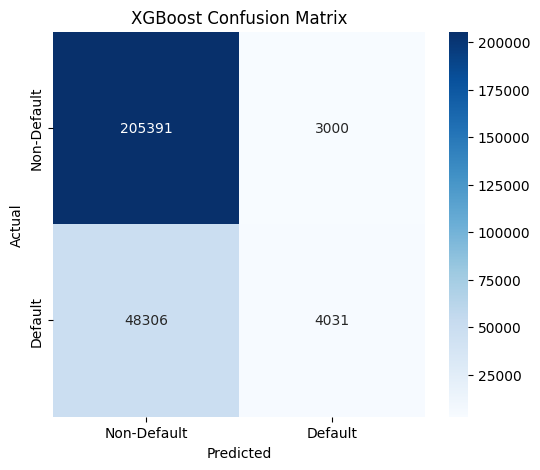

In [18]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Default", "Default"],
    yticklabels=["Non-Default", "Default"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [19]:
results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.803220,0.573318,0.077020,0.135797,0.719424
1,Random Forest,0.660593,0.324642,0.639471,0.430653,0.712369
0,Logistic Regression,0.661045,0.324098,0.634350,0.429010,0.708419


ROC-AUC Curve + final model selection.

Import ROC curve

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

Calculate ROC curves

In [21]:
fpr_log, tpr_log, _ = roc_curve(y_test, logistic_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

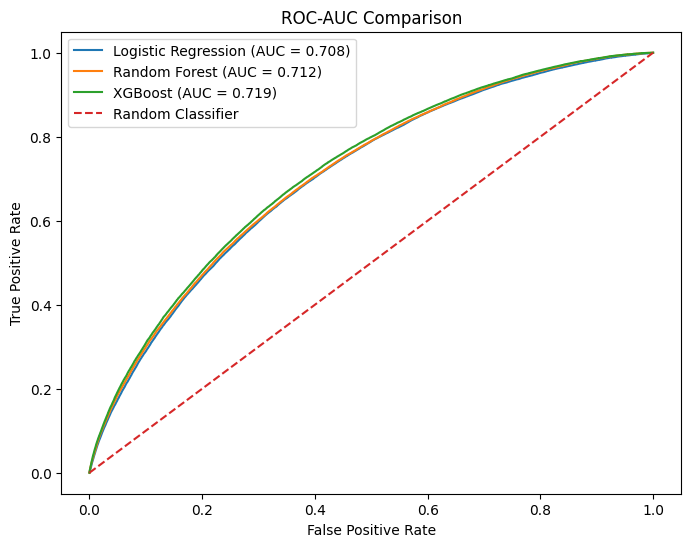

In [22]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log, tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    fpr_xgb, tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison")
plt.legend()
plt.show()

In [23]:
results.sort_values(
    by=["ROC-AUC", "F1 Score"],
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.803220,0.573318,0.077020,0.135797,0.719424
1,Random Forest,0.660593,0.324642,0.639471,0.430653,0.712369
0,Logistic Regression,0.661045,0.324098,0.634350,0.429010,0.708419


In [24]:
results.to_csv(
    "../data/processed/model_results.csv",
    index=False
)

print("Model evaluation results saved!")

Model evaluation results saved!
